In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report
)

In [4]:
DATASET_PATH = r"D:\GTSRB"

In [5]:
train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "Train.csv")
)

print(train_df.head())
print(train_df.columns)
print("Размер:", train_df.shape)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='str')
Размер: (39209, 8)


In [6]:
print("Количество классов:", train_df["ClassId"].nunique())

Количество классов: 43


In [7]:
print(train_df.iloc[0])

Width                                  27
Height                                 26
Roi.X1                                  5
Roi.Y1                                  5
Roi.X2                                 22
Roi.Y2                                 20
ClassId                                20
Path       Train/20/00020_00000_00000.png
Name: 0, dtype: object


In [8]:
image_path = os.path.join(DATASET_PATH, train_df.iloc[0]["Path"])

image = cv2.imread(image_path)

print("Путь:", image_path)
print("Изображение:", image.shape if image is not None else None)

Путь: D:\GTSRB\Train/20/00020_00000_00000.png
Изображение: (26, 27, 3)


In [9]:
class GTSRBDataset(Dataset):
    def __init__(self, dataframe, dataset_path):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_path = dataset_path

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = os.path.join(
            self.dataset_path,
            row["Path"]
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (32, 32))

        image = image.astype(np.float32) / 255.0

        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)

        label = int(row["ClassId"])

        return image, label

In [10]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ClassId"]
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)

Train: (31367, 8)
Validation: (7842, 8)


In [11]:
train_dataset = GTSRBDataset(
    train_data,
    DATASET_PATH
)

val_dataset = GTSRBDataset(
    val_data,
    DATASET_PATH
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 31367
Validation dataset: 7842


In [12]:
image, label = train_dataset[0]

print("Размер изображения:", image.shape)
print("Тип:", image.dtype)
print("Класс:", label)
print("Минимум:", image.min())
print("Максимум:", image.max())

Размер изображения: torch.Size([3, 32, 32])
Тип: torch.float32
Класс: 12
Минимум: tensor(0.0549)
Максимум: tensor(0.2431)


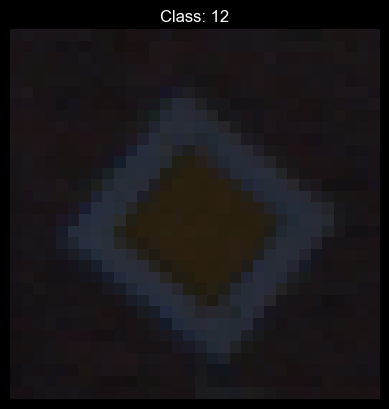

In [13]:
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Class: {label}")
plt.axis("off")
plt.show()

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 43)


    def forward(self, x):
        x = self.conv(x)

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [16]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
num_epochs = 20

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = correct / total


    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/20] Train Loss: 1.7604 Train Acc: 0.4872 Val Loss: 0.5247 Val Acc: 0.8599
Epoch [2/20] Train Loss: 0.5028 Train Acc: 0.8434 Val Loss: 0.2611 Val Acc: 0.9380
Epoch [3/20] Train Loss: 0.2826 Train Acc: 0.9142 Val Loss: 0.1491 Val Acc: 0.9611
Epoch [4/20] Train Loss: 0.1912 Train Acc: 0.9420 Val Loss: 0.1064 Val Acc: 0.9723
Epoch [5/20] Train Loss: 0.1463 Train Acc: 0.9574 Val Loss: 0.0726 Val Acc: 0.9823
Epoch [6/20] Train Loss: 0.1079 Train Acc: 0.9662 Val Loss: 0.0623 Val Acc: 0.9837
Epoch [7/20] Train Loss: 0.0942 Train Acc: 0.9702 Val Loss: 0.0579 Val Acc: 0.9852
Epoch [8/20] Train Loss: 0.0782 Train Acc: 0.9754 Val Loss: 0.0618 Val Acc: 0.9848
Epoch [9/20] Train Loss: 0.0674 Train Acc: 0.9792 Val Loss: 0.0477 Val Acc: 0.9885
Epoch [10/20] Train Loss: 0.0574 Train Acc: 0.9821 Val Loss: 0.0520 Val Acc: 0.9866
Epoch [11/20] Train Loss: 0.0512 Train Acc: 0.9834 Val Loss: 0.0483 Val Acc: 0.9883
Epoch [12/20] Train Loss: 0.0496 Train Acc: 0.9847 Val Loss: 0.0383 Val Acc: 0.9921
E

In [19]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())


print(classification_report(
    all_labels,
    all_predictions,
    digits=4
))

              precision    recall  f1-score   support

           0     1.0000    0.9524    0.9756        42
           1     0.9977    0.9910    0.9944       444
           2     0.9912    0.9956    0.9933       450
           3     0.9824    0.9894    0.9859       282
           4     0.9900    1.0000    0.9950       396
           5     0.9973    0.9785    0.9878       372
           6     1.0000    1.0000    1.0000        84
           7     0.9965    0.9757    0.9860       288
           8     0.9723    0.9965    0.9842       282
           9     0.9932    1.0000    0.9966       294
          10     0.9975    0.9975    0.9975       402
          11     1.0000    0.9962    0.9981       264
          12     1.0000    1.0000    1.0000       420
          13     0.9977    0.9977    0.9977       432
          14     1.0000    1.0000    1.0000       156
          15     0.9921    1.0000    0.9960       126
          16     1.0000    1.0000    1.0000        84
          17     1.0000    